Stage 1b — Exploratory analysis

Which conflict variables carry information about Brent crude returns, at what
lag, in which direction, and with what magnitude?

In [2]:
import json
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 50)

REPORTS = "results/reports"
FIGURES = "results/figures"
os.makedirs(REPORTS, exist_ok=True)
os.makedirs(FIGURES, exist_ok=True)

daily = pd.read_csv("datasets/processed/master_daily.csv", parse_dates=["date"]).set_index("date").sort_index()
weekly = pd.read_csv("datasets/processed/master_weekly.csv", parse_dates=["week_start"]).set_index("week_start").sort_index()
CONFLICT_ONSET = pd.Timestamp("2026-03-16")

How to read this notebook

Each section states what it is testing, shows the output, then says what the
output means. Where a result is null or inconclusive that is written down
rather than skipped, because a null result on a driver the project cares about
is the finding.

Two conventions carry through:

- **Returns, not levels.** The target is `log_return`, the return realised over
the next step. A model fitted on price levels scores near-perfectly and has
identified nothing.
- **Lag sign.** In every cross-correlation below, a positive lag means the
driver moved first. A spike at lag 0 is co-movement and supports no forecast.

Numbers shown here are also written to `results/reports/`, so anything quoted
downstream can be traced back to a file rather than to a cell that has since
been re-run.

Joining the weekly conflict data

ACLED variables are weekly; price and rhetoric are daily. Each is tested at its
own sampling frequency, and the grain of every column is reported so a
forward-filled series is never mistaken for a daily one.

In [5]:
from src.data.loaders import grain_report

weekly_ff = weekly.reindex(daily.index, method="ffill")
df = daily.join(weekly_ff)
grain = grain_report(df)
print(grain.to_string(index=False))
grain.to_csv(f"{REPORTS}/grain_report.csv", index=False)
print()
print("weekly columns are kept at weekly grain for inference below")

                  column  n_rows  n_update_events  change_rate                      grain  se_inflation
             brent_close     382              381        0.997                      daily          1.00
          rhetoric_index     382              381        0.997                      daily          1.00
         tanker_rate_usd     382              381        0.997                      daily          1.00
            acled_events     382               70        0.183 forward-filled (sub-daily)          2.34
        acled_fatalities     382               71        0.186 forward-filled (sub-daily)          2.32
acled_fatalities_revised     382               76        0.199 forward-filled (sub-daily)          2.24
         hormuz_severity     382               43        0.113 forward-filled (sub-daily)          2.98

weekly columns are kept at weekly grain for inference below


In [6]:
DRIVERS = [c for c in ["acled_events", "acled_fatalities", "acled_fatalities_revised",
                       "hormuz_severity", "rhetoric_index", "tanker_rate_usd"]
           if c in df.columns]
df[DRIVERS] = df[DRIVERS].ffill()
df = df.dropna(subset=DRIVERS)
print("drivers:", DRIVERS)
print("rows after dropping the unfilled leading period:", len(df))
print()
print(df[DRIVERS].describe().T.to_string())

drivers: ['acled_events', 'acled_fatalities', 'acled_fatalities_revised', 'hormuz_severity', 'rhetoric_index', 'tanker_rate_usd']
rows after dropping the unfilled leading period: 382

                          count          mean          std         min         25%          50%           75%         max
acled_events              382.0     23.267016    11.174442      9.0000     16.0000     19.00000     24.000000     55.0000
acled_fatalities          382.0     24.513089    27.476424      2.0000      9.0000     13.00000     19.000000    102.0000
acled_fatalities_revised  382.0     34.201571    37.762258      3.0000     13.0000     18.00000     25.000000    146.0000
hormuz_severity           382.0      1.486911     0.995310      0.0000      1.0000      1.00000      2.000000      4.0000
rhetoric_index            382.0      0.181360     0.223064     -0.3224      0.0308      0.15975      0.311775      0.9284
tanker_rate_usd           382.0  31029.959162  6354.115289  20972.6000  25192.9000  

Target

log_return at t is log(P_t+1 / P_t), the return realised over the next step.
Price levels are not modelled: an R-squared near 0.99 on levels means the model
has learned that today's price is close to yesterday's and has identified
nothing.

In [8]:
df["log_return"] = np.log(df["brent_close"].shift(-1) / df["brent_close"])
df["realised_return"] = np.log(df["brent_close"] / df["brent_close"].shift(1))
df = df.dropna(subset=["log_return"])
TARGET = "log_return"

print(df[TARGET].describe().to_string())
print()
print("annualised vol:", round(float(df[TARGET].std() * np.sqrt(252)), 4))
print("share of up days:", round(float((df[TARGET] > 0).mean()), 4))

count    381.000000
mean       0.000737
std        0.015044
min       -0.055069
25%       -0.008065
50%       -0.000249
75%        0.008561
max        0.060725

annualised vol: 0.2388
share of up days: 0.4856


Correlation matrix

                          acled_events  acled_fatalities  acled_fatalities_revised  hormuz_severity  rhetoric_index  tanker_rate_usd  log_return
acled_events                     1.000             0.940                     0.953            0.594           0.527            0.138       0.163
acled_fatalities                 0.940             1.000                     0.989            0.699           0.567            0.145       0.154
acled_fatalities_revised         0.953             0.989                     1.000            0.699           0.563            0.140       0.163
hormuz_severity                  0.594             0.699                     0.699            1.000           0.500           -0.015       0.081
rhetoric_index                   0.527             0.567                     0.563            0.500           1.000            0.106       0.041
tanker_rate_usd                  0.138             0.145                     0.140           -0.015           0.106            1.0

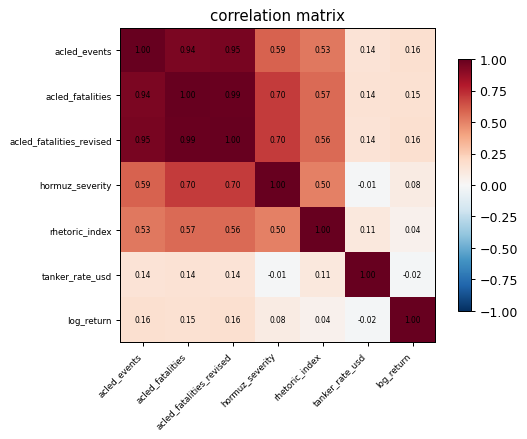

In [10]:
corr_cols = DRIVERS + [TARGET]
corr = df[corr_cols].corr()
print(corr.round(3).to_string())
corr.to_csv(f"{REPORTS}/correlation_matrix.csv")

fig, ax = plt.subplots(figsize=(6.5, 5))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha="right", fontsize=7)
ax.set_yticks(range(len(corr_cols)))
ax.set_yticklabels(corr_cols, fontsize=7)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center", fontsize=6)
fig.colorbar(im, shrink=.8)
ax.set_title("correlation matrix")
plt.tight_layout()

Stationarity — ADF and KPSS

The two tests have opposite nulls, so they can disagree. Both are reported with
statistic, p-value and lag order, and the verdict names any disagreement rather
than quietly reporting whichever is convenient.

In [12]:
from src.stats.diagnostics import stationarity_table

stat_cols = [c for c in [TARGET, "brent_close", "realised_return"] + DRIVERS if c in df.columns]
stat_cols = list(dict.fromkeys(stat_cols))
stat = stationarity_table(df[stat_cols])
print(stat.to_string(index=False))
stat.to_csv(f"{REPORTS}/stationarity.csv", index=False)

disagree = stat[stat["verdict"].str.startswith("disagree")]
print()
print(f"{len(disagree)} of {len(stat)} series give a disagreement between ADF and KPSS:")
for _, r in disagree.iterrows():
    print(f"  {r['column']:<28} {r['verdict']}")

with open(f"{REPORTS}/stationarity_report.txt", "w") as fh:
    print("STATIONARITY — ADF and KPSS", file=fh)
    print("statistic, p-value and lag order reported for both tests", file=fh)
    print(file=fh)
    print(stat.to_string(index=False), file=fh)

                  column   n  adf_stat  adf_p  adf_lag  kpss_stat  kpss_p  kpss_lag                     verdict
              log_return 381  -18.7343 0.0000        0     0.2344  0.1000         2     stationary (both agree)
             brent_close 381   -0.3651 0.9158        0     0.5258  0.0358        11 non-stationary (both agree)
         realised_return 380  -18.6981 0.0000        0     0.2366  0.1000         2     stationary (both agree)
            acled_events 381   -1.3369 0.6121        5     1.6347  0.0100        11 non-stationary (both agree)
        acled_fatalities 381   -0.2109 0.9372       15     1.7232  0.0100        11 non-stationary (both agree)
acled_fatalities_revised 381   -0.4622 0.8992       15     1.7011  0.0100        11 non-stationary (both agree)
         hormuz_severity 381   -1.1417 0.6981       15     1.2515  0.0100        11 non-stationary (both agree)
          rhetoric_index 381   -2.0080 0.2831        9     1.6854  0.0100        10 non-stationary (both

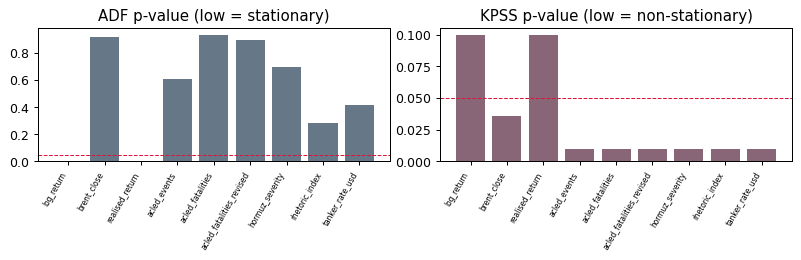

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3))
axes[0].bar(range(len(stat)), stat["adf_p"], color="#678")
axes[0].axhline(.05, ls="--", c="crimson", lw=.8)
axes[0].set_xticks(range(len(stat)))
axes[0].set_xticklabels(stat["column"], rotation=60, ha="right", fontsize=6)
axes[0].set_title("ADF p-value (low = stationary)")
axes[1].bar(range(len(stat)), stat["kpss_p"], color="#867")
axes[1].axhline(.05, ls="--", c="crimson", lw=.8)
axes[1].set_xticks(range(len(stat)))
axes[1].set_xticklabels(stat["column"], rotation=60, ha="right", fontsize=6)
axes[1].set_title("KPSS p-value (low = non-stationary)")
plt.tight_layout()

**Reading the table above.** ADF takes a unit root as its null, so a *low*
p-value argues for stationarity. KPSS takes stationarity as its null, so a
*low* p-value argues against it. The two therefore point in opposite
directions by construction, and the `verdict` column resolves each series
rather than quoting whichever test is convenient.

The case that matters is a disagreement: it usually means the series is
stationary around a trend, or that the sample is too short to decide. Either
way it is reported, not rounded off. Price levels failing and returns passing
is the expected pattern and the reason the target is a return.

Weekly-native testing

The ACLED variables are tested against a weekly-aggregated target, so the test
uses one observation per actual observation rather than one per forward-filled
daily row.

In [16]:
from scipy import stats as _st

weekly_target = df[TARGET].resample("W-MON").sum().rename("weekly_return")
weekly_join = weekly.join(weekly_target, how="inner").dropna()
print("weekly observations available for inference:", len(weekly_join))
print()

wk_rows = []
for col in [c for c in weekly.columns if c in weekly_join.columns]:
    pair = weekly_join[[col, "weekly_return"]].dropna()
    if len(pair) > 10:
        r, p = _st.pearsonr(pair[col], pair["weekly_return"])
        wk_rows.append({"driver": col, "grain": "weekly", "pearson_r": round(float(r), 4),
                        "p_value": round(float(p), 4), "n": len(pair)})
weekly_tests = pd.DataFrame(wk_rows)
print(weekly_tests.to_string(index=False))
weekly_tests.to_csv(f"{REPORTS}/weekly_native_tests.csv", index=False)
print()
print("n here is weekly observations, not the daily row count.")

weekly observations available for inference: 77

                  driver  grain  pearson_r  p_value  n
            acled_events weekly     0.3411   0.0024 77
        acled_fatalities weekly     0.3350   0.0029 77
acled_fatalities_revised weekly     0.3505   0.0018 77
         hormuz_severity weekly     0.2359   0.0389 77

n here is weekly observations, not the daily row count.


**Why this section exists.** The daily frame carries the ACLED columns
forward-filled, so the same weekly value repeats across five rows. A
correlation computed on those rows counts each observation five times and
reports a sample size that is roughly five times too large. The test above uses
one row per genuine weekly observation, so its `n` is the real one.

If the daily and weekly results disagree, the weekly one is the one to believe.

Significance of the driver-target links

Every relationship carries a p-value and the significance band. A correlation
coefficient on its own is not a finding.

In [19]:
from scipy import stats as sps

rows = []
for col in DRIVERS:
    pair = df[[col, TARGET]].dropna()
    r, p = sps.pearsonr(pair[col], pair[TARGET])
    rho, rho_p = sps.spearmanr(pair[col], pair[TARGET])
    band = 1.96 / np.sqrt(len(pair))
    rows.append({"driver": col, "pearson_r": round(float(r), 4), "pearson_p": round(float(p), 4),
                 "spearman_rho": round(float(rho), 4), "spearman_p": round(float(rho_p), 4),
                 "band": round(float(band), 4), "significant": bool(abs(r) > band), "n": len(pair)})
sig = pd.DataFrame(rows).sort_values("pearson_p").reset_index(drop=True)
print(sig.to_string(index=False))
sig.to_csv(f"{REPORTS}/significance.csv", index=False)

n_sig = int(sig["significant"].sum())
print()
print(f"{n_sig} of {len(sig)} drivers clear the band at the 5% level.")

                  driver  pearson_r  pearson_p  spearman_rho  spearman_p   band  significant   n
            acled_events     0.1630     0.0014        0.1030      0.0445 0.1004         True 381
acled_fatalities_revised     0.1627     0.0014        0.0671      0.1913 0.1004         True 381
        acled_fatalities     0.1537     0.0026        0.0543      0.2909 0.1004         True 381
         hormuz_severity     0.0806     0.1161        0.0551      0.2832 0.1004        False 381
          rhetoric_index     0.0411     0.4235       -0.0126      0.8057 0.1004        False 381
         tanker_rate_usd    -0.0214     0.6772       -0.0395      0.4419 0.1004        False 381

3 of 6 drivers clear the band at the 5% level.


**What passes and what does not.** The band is 1.96/sqrt(N): a coefficient
inside it is indistinguishable from zero at conventional levels. Spearman is
shown next to Pearson because the conflict counts are skewed and bounded below
at zero, where a rank correlation is the more honest summary.

A driver that clears the band here has still only cleared a contemporaneous
test. Whether it *leads* the target is the next section's question, and it is a
different one.

Lag structure — cross-correlation and Granger

Sign convention: a bar at a POSITIVE lag means the driver moved first and the
target followed, which is the only configuration that supports a forecast. A
spike at lag 0 is co-movement and supports nothing.

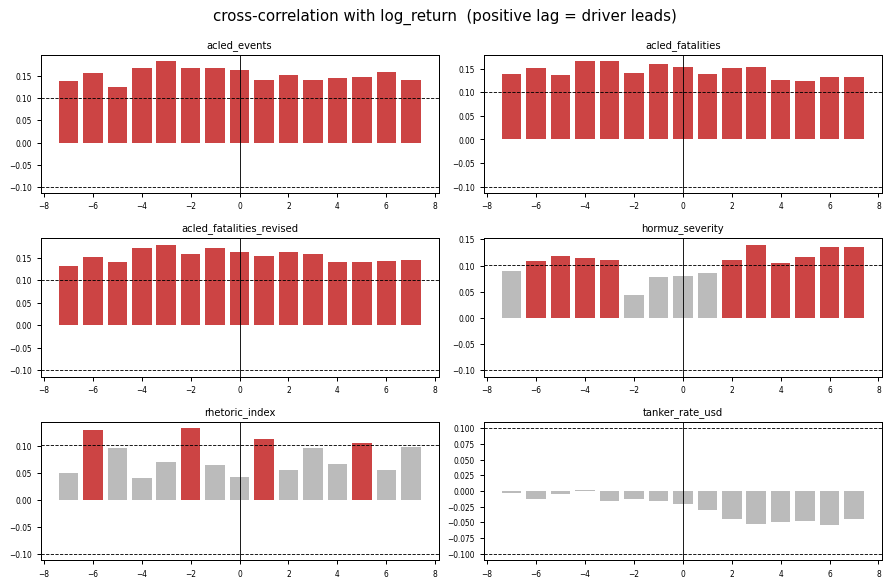

In [22]:
from src.stats.diagnostics import cross_correlation, granger_table

ccf_frames = {}
for col in DRIVERS:
    ccf_frames[col] = cross_correlation(df[col], df[TARGET], max_lag=7)

n_cols = 2
n_rows = int(np.ceil(len(DRIVERS) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 2.2 * n_rows), squeeze=False)
for ax, col in zip(axes.ravel(), DRIVERS):
    cc = ccf_frames[col]
    ax.bar(cc["lag"], cc["ccf"], color=["#c44" if s else "#bbb" for s in cc["significant"]])
    ax.axhline(float(cc["band"].iloc[0]), ls="--", lw=.7, c="k")
    ax.axhline(-float(cc["band"].iloc[0]), ls="--", lw=.7, c="k")
    ax.axvline(0, lw=.7, c="k")
    ax.set_title(col, fontsize=8)
    ax.tick_params(labelsize=6)
for ax in axes.ravel()[len(DRIVERS):]:
    ax.axis("off")
fig.suptitle("cross-correlation with " + TARGET + "  (positive lag = driver leads)")
plt.tight_layout()

In [23]:
for col in DRIVERS:
    cc = ccf_frames[col]
    lead = cc[cc["lag"] > 0]
    best = lead.iloc[lead["ccf"].abs().to_numpy().argmax()]
    at_zero = float(cc[cc["lag"] == 0]["ccf"].iloc[0])
    print(f"{col:<28} best lead lag {int(best['lag']):+d}  ccf {float(best['ccf']):+.4f}  "
          f"sig {bool(best['significant'])}   lag0 {at_zero:+.4f}")

acled_events                 best lead lag +6  ccf +0.1584  sig True   lag0 +0.1630
acled_fatalities             best lead lag +3  ccf +0.1533  sig True   lag0 +0.1537
acled_fatalities_revised     best lead lag +2  ccf +0.1621  sig True   lag0 +0.1627
hormuz_severity              best lead lag +3  ccf +0.1402  sig True   lag0 +0.0806
rhetoric_index               best lead lag +1  ccf +0.1116  sig True   lag0 +0.0411
tanker_rate_usd              best lead lag +6  ccf -0.0544  sig False   lag0 -0.0214


In [24]:
granger_rows = []
for col in DRIVERS:
    gt = granger_table(df[col], df[TARGET], max_lag=7)
    if len(gt):
        best = gt.loc[gt["p_value"].idxmin()]
        granger_rows.append({"driver": col, "best_lag": int(best["lag"]),
                             "f_stat": float(best["f_stat"]), "p_value": float(best["p_value"]),
                             "n": int(best["n"])})
granger = pd.DataFrame(granger_rows).sort_values("p_value")
print(granger.to_string(index=False))
granger.to_csv(f"{REPORTS}/granger.csv", index=False)
print()
print("Granger gives predictive precedence, not causation. These read as 'precedes'.")

                  driver  best_lag  f_stat  p_value   n
acled_fatalities_revised         1  8.9728   0.0029 381
        acled_fatalities         2  5.8634   0.0031 381
            acled_events         1  7.3623   0.0070 381
          rhetoric_index         1  4.7141   0.0305 381
         hormuz_severity         3  2.7642   0.0418 381
         tanker_rate_usd         2  1.7796   0.1701 381

Granger gives predictive precedence, not causation. These read as 'precedes'.


**How to read the panels.** Red bars clear the significance band; grey bars do
not. Bars to the right of zero are the only ones that could support a forecast,
because only there did the driver move before the target. A tall bar at lag 0
with nothing to its right means the two series move together and neither
predicts the other — which is a common and easily misread pattern.

The Granger table asks a narrower question: does adding lags of the driver
reduce forecast error for the target beyond the target's own history? A low
p-value means it does. That is predictive precedence and nothing more; none of
these results licence the word "causes".

Multicollinearity — VIF

Required for any candidate set larger than three. A VIF above 5 means the
driver is largely reconstructible from the others and its coefficient cannot be
read on its own.

                 feature    vif
acled_fatalities_revised 58.503
        acled_fatalities 44.543
            acled_events 12.154
         hormuz_severity  2.348
          rhetoric_index  1.528
         tanker_rate_usd  1.055

above 5, so collinear with the rest of the set:
  acled_fatalities_revised     58.503
  acled_fatalities             44.543
  acled_events                 12.154
only one of any collinear pair should enter a model.


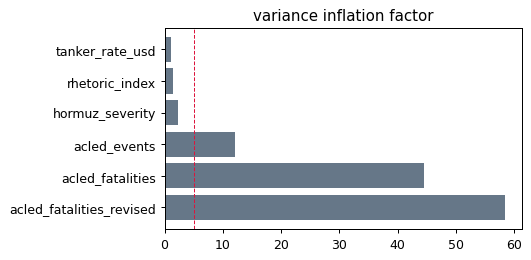

In [27]:
from src.stats.diagnostics import vif_table

vif = vif_table(df[DRIVERS])
print(vif.to_string(index=False))
vif.to_csv(f"{REPORTS}/vif.csv", index=False)

high = vif[vif["vif"] > 5]
print()
if len(high):
    print("above 5, so collinear with the rest of the set:")
    for _, r in high.iterrows():
        print(f"  {r['feature']:<28} {float(r['vif']):.3f}")
    print("only one of any collinear pair should enter a model.")
else:
    print("no driver exceeds a VIF of 5.")

fig, ax = plt.subplots(figsize=(6, 3))
ax.barh(vif["feature"], vif["vif"], color="#678")
ax.axvline(5, ls="--", c="crimson", lw=.8)
ax.set_title("variance inflation factor")
plt.tight_layout()

**Why this gates the modelling stage.** The ACLED event and fatality counts
measure overlapping things, so they carry much of the same information. When
collinear features enter a model together the fit is unaffected but the
individual coefficients become unstable and can flip sign between samples.

A VIF above 5 means the feature is largely reconstructible from the others.
The fix is to keep one of each collinear pair, not to keep both and interpret
them separately.

Regime split at conflict onset

A break is half a finding until it says whether the mean or the variance moved.

In [30]:
from src.stats.diagnostics import structural_break

brk = structural_break(df[TARGET], CONFLICT_ONSET)
for k, v in brk.items():
    print(f"{k:>14}: {v}")
print()
print("WHAT MOVED:", brk["what_moved"])
with open(f"{REPORTS}/regime_split.json", "w") as fh:
    json.dump(brk, fh, indent=2)

    breakpoint: 2026-03-16
      n_before: 305
       n_after: 76
   mean_before: -0.000395
    mean_after: 0.005278
    std_before: 0.012018
     std_after: 0.023132
       welch_t: -2.0696
       welch_p: 0.0415
   levene_stat: 53.4752
      levene_p: 0.0
    what_moved: mean and variance

WHAT MOVED: mean and variance


In [31]:
pre = df[df.index < CONFLICT_ONSET]
post = df[df.index >= CONFLICT_ONSET]
print(f"pre-onset  n={len(pre)}   post-onset n={len(post)}")
print()
comp = pd.DataFrame({
    "pre_mean": pre[DRIVERS + [TARGET]].mean(),
    "post_mean": post[DRIVERS + [TARGET]].mean(),
    "pre_std": pre[DRIVERS + [TARGET]].std(),
    "post_std": post[DRIVERS + [TARGET]].std(),
})
comp["std_ratio"] = (comp["post_std"] / comp["pre_std"]).round(3)
print(comp.round(5).to_string())
comp.to_csv(f"{REPORTS}/regime_comparison.csv")

pre-onset  n=305   post-onset n=76

                             pre_mean    post_mean     pre_std    post_std  std_ratio
acled_events                 18.36066     42.61842     3.98613     9.15054      2.296
acled_fatalities             11.39344     76.14474     4.44735    16.54062      3.719
acled_fatalities_revised     16.11475    105.52632     5.70981    22.45260      3.932
hormuz_severity               1.11475      2.94737     0.70474     0.45883      0.651
rhetoric_index                0.11459      0.44611     0.17870     0.18269      1.022
tanker_rate_usd           30579.29475  32888.10658  6779.18452  3782.80553      0.558
log_return                   -0.00040      0.00528     0.01202     0.02313      1.925


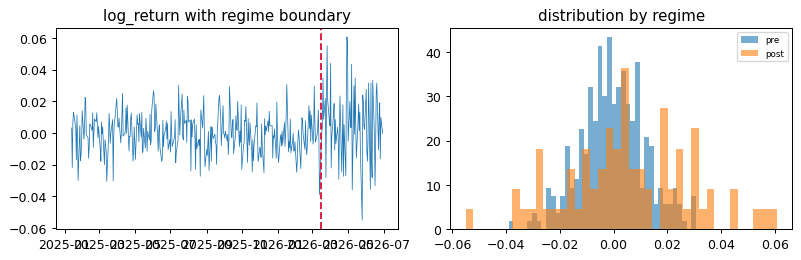

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3))
axes[0].plot(df.index, df[TARGET], lw=.6)
axes[0].axvline(CONFLICT_ONSET, color="crimson", ls="--")
axes[0].set_title(TARGET + " with regime boundary")
axes[1].hist(pre[TARGET].dropna(), bins=40, alpha=.6, label="pre", density=True)
axes[1].hist(post[TARGET].dropna(), bins=40, alpha=.6, label="post", density=True)
axes[1].legend(fontsize=7)
axes[1].set_title("distribution by regime")
plt.tight_layout()

**Mean versus variance.** These are different findings and get confused
constantly. A mean shift says the typical daily return changed. A variance
shift says the size of the moves changed while their average stayed put. The
Welch test addresses the first, Levene the second, and the verdict names
whichever moved.

For this project the variance answer is usually the substantive one: conflict
periods look like volatility events rather than directional ones, and a
strategy built on an expected direction that did not move would be built on
the wrong half of the result.

Ranked drivers

Every row carries direction, magnitude, lag and a p-value. Three of four is not
a result.

In [35]:
from src.stats.diagnostics import driver_ranking

ranking = driver_ranking(df[DRIVERS], df[TARGET], max_lag=7)
print(ranking.to_string(index=False))
ranking.to_csv(f"{REPORTS}/driver_ranking.csv", index=False)

                  driver  best_lead_lag  magnitude direction  ccf_significant   band  granger_min_p   n
acled_fatalities_revised              2     0.1621  positive             True 0.1004         0.0029 381
            acled_events              6     0.1584  positive             True 0.1004         0.0070 381
        acled_fatalities              3     0.1533  positive             True 0.1004         0.0031 381
         hormuz_severity              3     0.1402  positive             True 0.1004         0.0418 381
          rhetoric_index              1     0.1116  positive             True 0.1004         0.0305 381
         tanker_rate_usd              6     0.0544  negative            False 0.1004         0.1701 381


acled_fatalities_revised     lag +2  positive magnitude 0.1621  granger p 0.0029  -> supports a forecast
acled_events                 lag +6  positive magnitude 0.1584  granger p 0.007  -> supports a forecast
acled_fatalities             lag +3  positive magnitude 0.1533  granger p 0.0031  -> supports a forecast
hormuz_severity              lag +3  positive magnitude 0.1402  granger p 0.0418  -> supports a forecast
rhetoric_index               lag +1  positive magnitude 0.1116  granger p 0.0305  -> supports a forecast
tanker_rate_usd              lag +6  negative magnitude 0.0544  granger p 0.1701  -> within noise


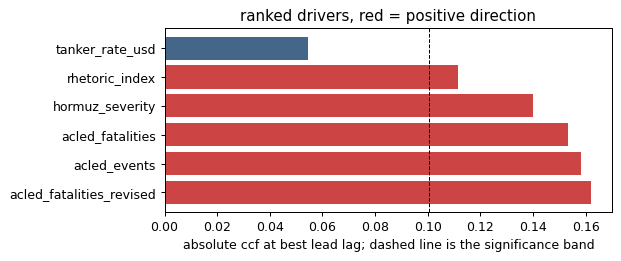

In [36]:
if len(ranking):
    fig, ax = plt.subplots(figsize=(7, 3))
    colours = ["#c44" if d == "positive" else "#468" for d in ranking["direction"]]
    ax.barh(ranking["driver"], ranking["magnitude"], color=colours)
    ax.axvline(float(ranking["band"].iloc[0]), ls="--", c="k", lw=.8)
    ax.set_xlabel("absolute ccf at best lead lag; dashed line is the significance band")
    ax.set_title("ranked drivers, red = positive direction")
    plt.tight_layout()

    for _, r in ranking.iterrows():
        verdict = "supports a forecast" if r["ccf_significant"] else "within noise"
        print(f"{r['driver']:<28} lag {int(r['best_lead_lag']):+d}  "
              f"{r['direction']:<8} magnitude {float(r['magnitude']):.4f}  "
              f"granger p {r['granger_min_p']}  -> {verdict}")

**What each column is for.** Direction without magnitude does not size a
position. Magnitude without a lag does not say when. Either without a p-value
does not say whether it is there at all. A row is only usable with all four, so
the table is built to make dropping one awkward.

`granger_min_p` is the smallest p-value across the tested lags, which means it
has been minimised over seven chances. Treat it as a screening figure rather
than an inferential one.

Summary

In [39]:
lines = ["EDA SUMMARY", "=" * 70, ""]
if len(ranking):
    top = ranking.iloc[0]
    lines.append("Top driver: " + str(top["driver"]) + " at lag "
                 + str(int(top["best_lead_lag"])) + ", " + str(top["direction"])
                 + ", magnitude " + str(top["magnitude"])
                 + ", granger p " + str(top["granger_min_p"]))
else:
    lines.append("No driver produced a usable lead relationship.")
lines.append("Stationarity: " + str(len(disagree)) + " of " + str(len(stat)) + " series give an ADF/KPSS disagreement")
lines.append("Significance: " + str(n_sig) + " of " + str(len(sig)) + " drivers clear the band")
lines.append("Multicollinearity: " + str(len(high)) + " driver(s) above VIF 5")
lines.append("Regime break at onset: " + brk["what_moved"])
lines.append("")
lines.append("Not supported by this data: any causal claim. Inventories, dollar")
lines.append("strength and demand are absent from the dataset, so the supportable")
lines.append("phrasing is that volatility rose during the conflict period, not")
lines.append("that the conflict caused the move.")

with open(f"{REPORTS}/feature_relationships.txt", "w") as fh:
    for line in lines:
        print(line, file=fh)
for line in lines:
    print(line)
print()
print("wrote", f"{REPORTS}/feature_relationships.txt")

EDA SUMMARY

Top driver: acled_fatalities_revised at lag 2, positive, magnitude 0.1621, granger p 0.0029
Stationarity: 0 of 9 series give an ADF/KPSS disagreement
Significance: 3 of 6 drivers clear the band
Multicollinearity: 3 driver(s) above VIF 5
Regime break at onset: mean and variance

Not supported by this data: any causal claim. Inventories, dollar
strength and demand are absent from the dataset, so the supportable
phrasing is that volatility rose during the conflict period, not
that the conflict caused the move.

wrote results/reports/feature_relationships.txt
